# Transformaciones a Tiempo-Frecuencia


In [28]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [29]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.316971,-0.009932,-0.425399,-0.178523,-0.494695,-0.433637,-0.376319,-0.087012,-0.367599,-0.179203,-0.065061,-0.206498,0.295136,0.311536,0,0.000000
1,0.148518,-0.261323,-0.037807,0.000146,-1.887244,-0.401899,-0.310983,-0.504367,-1.656623,-1.487171,-0.371773,-0.286736,0.059742,-0.096744,0,0.007812
2,0.238763,-0.152552,0.258011,0.428687,-2.286898,-0.829564,-0.284813,-0.935728,-1.394720,-1.576502,-0.374950,0.011409,-0.002535,0.073527,0,0.015625
3,0.364411,0.140839,0.320441,0.498201,-1.508022,-0.950506,-0.305047,-1.126591,-0.857133,-0.378787,-0.068891,0.567911,0.115806,0.539387,0,0.023438
4,0.223380,0.102305,-0.028270,0.257180,-0.774204,-0.464788,-0.393875,-1.558265,-1.449961,0.302875,0.184332,0.703156,0.188856,0.642532,0,0.031250


## Transformada de fourier de corto plazo


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [31]:
def apply_stft(series, fs = FS, window_sec = 2, overlap_pct = 0.75):
    # Ventana de 2s → Δf = 0.5 Hz (10 bins en banda alfa 8-13 Hz)
    # Tradeoff: mejor resolución frecuencial a costa de resolución temporal (Δt = 0.5s)
    # La CWT supera esta limitación con análisis multiresolución
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)

    f, t, Zxx = stft(series, fs=fs, window='hann', nperseg=n_per_seg, noverlap=n_overlap)
    power = np.abs(Zxx) ** 2 # para comparar con WT, se debe calcular la potencia espectral (amplitud al cuadrado)
    
    return f, t, power

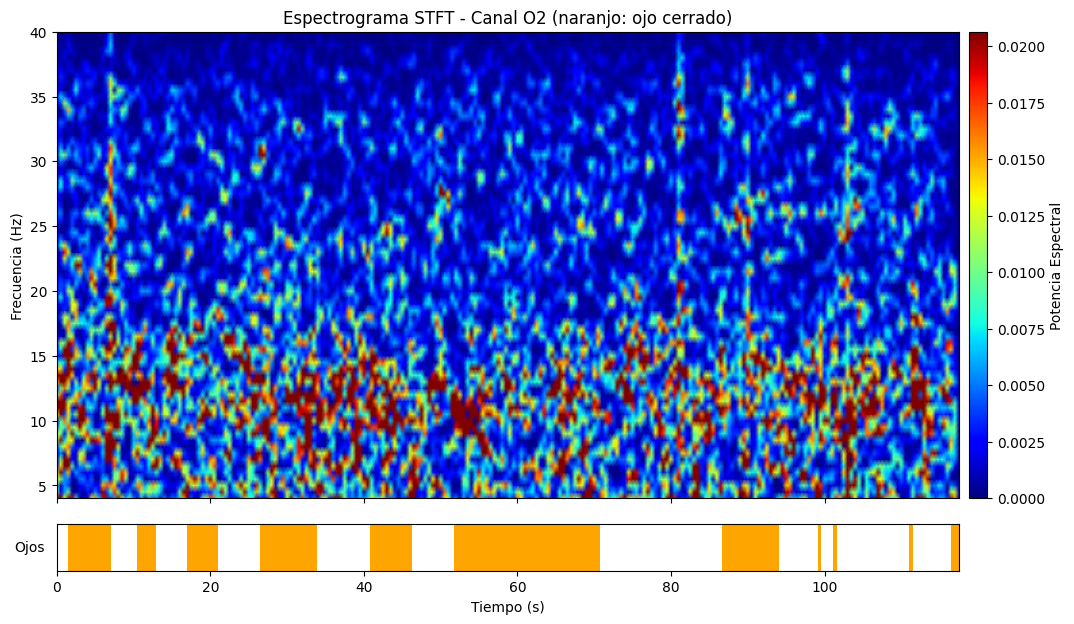

In [32]:
# --- Computar STFT para los 14 canales ---
stft_arrays = {}
stft_freqs, stft_times = None, None

for ch in CHANNELS:
    f, t, power = apply_stft(df[ch])
    
    # Recortar al mismo rango que la CWT aplicada posteriormente (4–40 Hz)
    # Así ambas representaciones analizan exactamente las mismas bandas
    # y la comparación downstream es metodológicamente válida
    freq_mask    = (f >= 4) & (f <= 40)
    stft_arrays[ch] = power[freq_mask, :]

    if stft_freqs is None:
        stft_freqs = f[freq_mask]
        stft_times = t

labels_stft = np.array([
    df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL]
    for ti in stft_times
])

# --- Visualización O2 ---
target = 'O2'
psd_viz = stft_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(stft_times, stft_freqs, psd_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(psd_viz, 95))
ax1.set_title(f'Espectrograma STFT - Canal {target} (naranjo: ojo cerrado)')
ax1.set_ylabel('Frecuencia (Hz)')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia Espectral')
states_matrix = labels_stft.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[stft_times.min(), stft_times.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(stft_times.min(), stft_times.max())
ax2.set_xlim(stft_times.min(), stft_times.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
cax2.axis('off')
plt.show()

## Transformada de Wavelet Continua (CWT)


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [34]:
def apply_cwt(series, fs=FS, freq_min=4, freq_max=40, n_freqs=80, wavelet='cmor1.5-1.0'):
    """
    Aplica la Transformada Wavelet Continua (CWT) a una señal EEG.

    Parámetros
    ----------
    series    : array-like  - Señal de entrada (1D).
    fs        : int         - Frecuencia de muestreo en Hz.
    freq_min  : float       - Frecuencia mínima de análisis en Hz (default: 4 Hz, inicio de banda theta).
    freq_max  : float       - Frecuencia máxima de análisis en Hz (default: 40 Hz, consistente con filtro).
    n_freqs   : int         - Número de escalas (resolución frecuencial).
    wavelet   : str         - Wavelet madre. Se usa Morlet compleja (cmor) por
                              su localización conjunta tiempo-frecuencia.

    Retorna
    -------
    freqs     : ndarray     - Frecuencias correspondientes a cada escala (Hz).
    t         : ndarray     - Vector de tiempo (s).
    power     : ndarray     - Densidad de potencia espectral |CWT|² (freqs x tiempo).
    """
    # Calcular escalas a partir del rango de frecuencias deseado
    # pywt.scale2frequency convierte escala → frecuencia: f = f_c / (escala * dt)
    dt = 1.0 / fs
    central_freq = pywt.central_frequency(wavelet)
    
    # Espaciado LOGARÍTMICO de frecuencias (no lineal).
    # la CWT es un análisis multi-resolución por naturaleza — a bajas
    # frecuencias usa wavelets largos (alta res. frecuencial) y a altas frecuencias
    # usa wavelets cortos (alta res. temporal). El log-spacing respeta esa geometría, pues
    # distribuye los n_freqs bins uniformemente por octava (4-8 Hz, 8-16 Hz, 16-32 Hz),
    # en vez de concentrarlos artificialmente en las frecuencias bajas como hace linspace.
    # Esto es coherente con la literatura EEG y con la comparación frente a la STFT,
    # cuya resolución uniforme (lineal) es precisamente la limitación que la CWT supera.
    freqs_desired = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)
    
    scales = central_freq / (freqs_desired * dt)
    scales = scales[::-1]  # ordenar de menor a mayor escala (mayor a menor frecuencia)

    signal = np.array(series, dtype=np.float64)
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)

    # Densidad de potencia: módulo al cuadrado de los coeficientes complejos
    power = np.abs(coeffs) ** 2
    t = np.arange(len(signal)) * dt

    return freqs, t, power

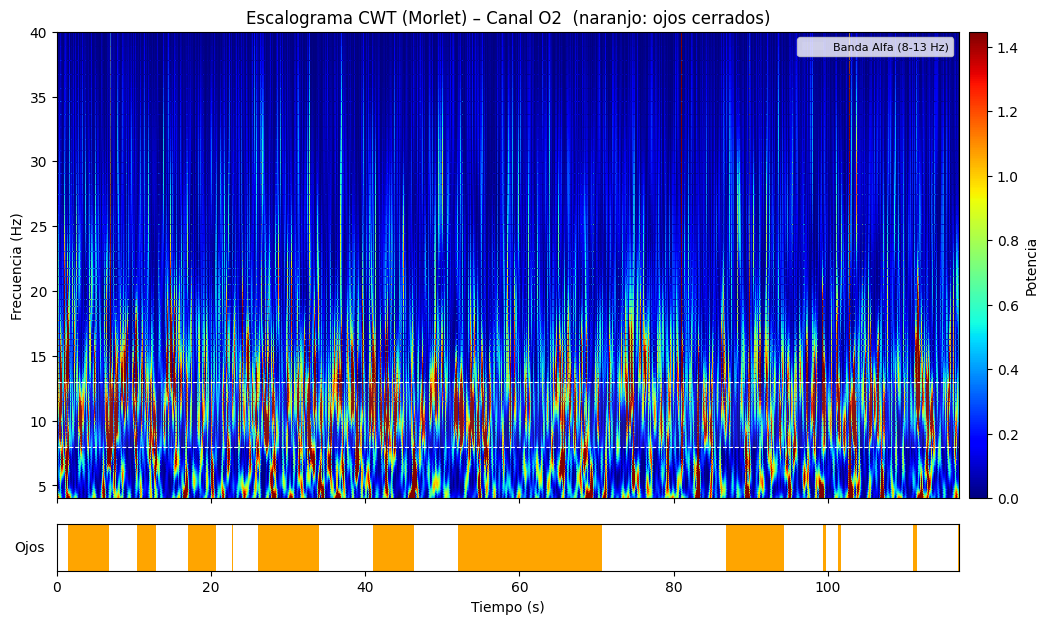

In [35]:
# --- Computar CWT para los 14 canales ---
cwt_arrays = {}
cwt_freqs_arr, cwt_times_arr = None, None

for ch in CHANNELS:
    freqs_cwt, t_cwt, power = apply_cwt(df[ch], fs=FS)
    cwt_arrays[ch] = power
    if cwt_freqs_arr is None:
        cwt_freqs_arr = freqs_cwt
        cwt_times_arr = t_cwt

# La CWT preserva la resolución temporal original (una columna por muestra),
# por lo que los labels están perfectamente alineados con los índices del df.
# No se necesita búsqueda — asignación directa O(1) en vez de O(N²).
labels_cwt = df[TARGET_COL].values

# --- Visualización O2 ---
target    = 'O2'
power_viz = cwt_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(cwt_times_arr, cwt_freqs_arr, power_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(power_viz, 95))
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8-13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)
ax1.set_title(f'Escalograma CWT (Morlet) – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')
states_matrix = labels_cwt.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[cwt_times_arr.min(), cwt_times_arr.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
ax2.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

### Cono de Influencia (CoI)

La CWT utiliza wavelets de extensión temporal variable: a bajas frecuencias el wavelet 
es más largo y requiere mayor contexto temporal para calcular correctamente el coeficiente. 
Cerca de los bordes de la señal (t=0 y t=T_total), el wavelet se extiende parcialmente 
fuera del registro — esa zona se rellena con ceros — produciendo coeficientes no confiables. 
Esta región contaminada se denomina **Cono de Influencia (CoI)**.

#### Fórmula para `cmor{B}-{C}`

La envolvente gaussiana del wavelet de Morlet complejo tiene desviación estándar 
temporal $\sigma_t = \sqrt{B/2}$. A partir de esto, el *e-folding time* (tiempo 
característico de decaimiento de la envolvente) para una escala $s$ es:

$$\tau(s) = \sqrt{2} \cdot \sigma_t \cdot s \cdot dt = \sqrt{B} \cdot s \cdot dt$$

Reexpresando en función de la frecuencia, usando la relación $s = f_c\, /\, (f \cdot dt)$:

$$\tau(f) = \frac{\sqrt{B} \cdot f_c}{f}$$

donde $f_c$ es la frecuencia central del wavelet madre.

Para **`cmor1.5-1.0`**: $B = 1.5$, $f_c \approx 1.0$ Hz, por lo tanto:

$$\tau(f) = \frac{\sqrt{1.5}}{f} \approx \frac{1.225}{f} \quad \text{[segundos]}$$

| Frecuencia | CoI desde cada borde |
|:---:|:---:|
| 4 Hz  | 0.31 s |
| 8 Hz  | 0.15 s |
| 13 Hz | 0.09 s |
| 40 Hz | 0.03 s |

> **Nota:** con 117 s de registro el CoI es pequeño (< 0.31 s en todas las frecuencias 
> analizadas). Sin embargo, se marca en la visualización por rigor metodológico. 
> En el notebook de extracción de características, las ventanas temporales deberán 
> excluir esta región fronteriza.

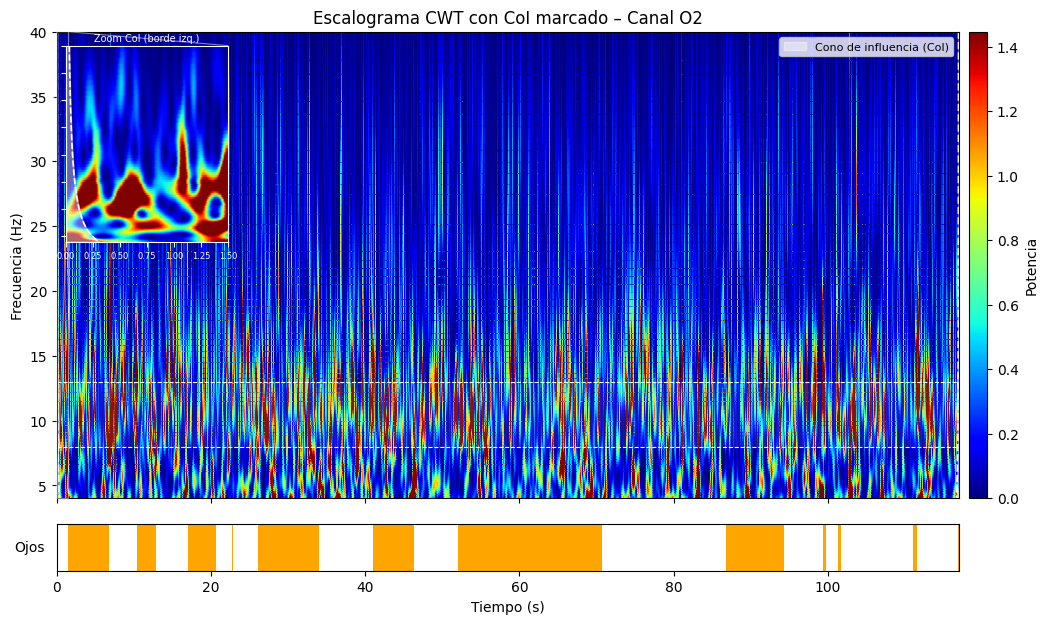

CoI máximo (f=4 Hz): 0.306 s → 0.26% del registro
CoI mínimo (f=40 Hz): 0.0306 s → 0.026% del registro


In [36]:
B       = 1.5  # bandwidth de cmor1.5-1.0
f_c     = pywt.central_frequency('cmor1.5-1.0')
T_total = cwt_times_arr[-1]

# Tiempo de CoI para cada frecuencia analizada
coi_times = np.sqrt(B) * f_c / cwt_freqs_arr  # shape: (n_freqs,)

target    = 'O2'
power_viz = cwt_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)

im = ax1.pcolormesh(cwt_times_arr, cwt_freqs_arr, power_viz, shading='gouraud',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))

# Banda alfa
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0)
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)

# CoI: zona sombreada + línea de frontera
ax1.fill_betweenx(cwt_freqs_arr, 0, coi_times,
                  color='white', alpha=0.4, label='Cono de influencia (CoI)')
ax1.fill_betweenx(cwt_freqs_arr, T_total - coi_times, T_total,
                  color='white', alpha=0.4)
ax1.plot(coi_times,           cwt_freqs_arr, 'w--', linewidth=1.4)
ax1.plot(T_total - coi_times, cwt_freqs_arr, 'w--', linewidth=1.4)

ax1.set_title(f'Escalograma CWT con CoI marcado – Canal {target}')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')

# ── Inset: zoom en borde izquierdo para visualizar el CoI ─────────────────
# El CoI máximo es ~0.31s, invisible en la escala de 117s.
# El inset muestra los primeros 1.5s donde la forma del cono es apreciable.
ZOOM_MAX_T = 1.5  # segundos a mostrar en el inset
t_mask = cwt_times_arr <= ZOOM_MAX_T

ax_inset = ax1.inset_axes([0.01, 0.55, 0.18, 0.42])  # [x, y, ancho, alto] en fracción de ax1
ax_inset.pcolormesh(cwt_times_arr[t_mask], cwt_freqs_arr,
                    power_viz[:, t_mask], shading='gouraud',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))

ax_inset.fill_betweenx(cwt_freqs_arr, 0, coi_times,
                       color='white', alpha=0.4)
ax_inset.plot(coi_times, cwt_freqs_arr, 'w--', linewidth=1.2)

ax_inset.set_xlim(0, ZOOM_MAX_T)
ax_inset.set_ylim(cwt_freqs_arr.min(), cwt_freqs_arr.max())
ax_inset.set_title('Zoom CoI (borde izq.)', fontsize=7, color='white', pad=3)
ax_inset.tick_params(labelsize=6, colors='white')
ax_inset.set_facecolor('black')
for spine in ax_inset.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(0.8)

# Rectángulo indicando la región del inset en el plot principal
ax1.indicate_inset_zoom(ax_inset, edgecolor='white', linewidth=0.8)

# ── Barra de estado ocular ─────────────────────────────────────────────────
states_matrix = labels_cwt.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[cwt_times_arr.min(), cwt_times_arr.max(), 0, 1],
           interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(0, T_total)
ax2.set_xlim(0, T_total)
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

print("CoI máximo (f={:.0f} Hz): {:.3f} s → {:.2f}% del registro".format(
    cwt_freqs_arr.min(), coi_times.max(), 100 * coi_times.max() / T_total))
print("CoI mínimo (f={:.0f} Hz): {:.4f} s → {:.3f}% del registro".format(
    cwt_freqs_arr.max(), coi_times.min(), 100 * coi_times.min() / T_total))

## Synchrosqueezing Transform (SST)

La SST parte de la misma CWT ya calculada, pero corrige una de sus
limitaciones intrínsecas: el **blur** o esparcimiento de energía. Cuando un
wavelet analiza una oscilación pura, su energía no queda concentrada en una
única frecuencia sino distribuida en un rango, según el ancho de banda
propio del wavelet. Esto hace que el escalograma se vea "borroso" alrededor
de cada componente real de la señal.

La SST corrige esto en dos pasos:

1. Calcula la CWT normalmente (igual que antes).
2. Para cada coeficiente, estima la **frecuencia instantánea real** a partir
   de la derivada de la fase de ese coeficiente, y reasigna ("squeezes") la
   energía de ese punto hacia esa frecuencia verdadera, en lugar de dejarla
   en la frecuencia nominal del wavelet usado.

El resultado es una representación más nítida — la energía de una oscilación
pura aparece concentrada en una línea fina en lugar de una banda difusa.
Esto es especialmente valioso para el ritmo alfa, que es una oscilación
relativamente angosta y bien definida en frecuencia.

 > La extracción de features sobre la SST será idéntica a la de la CWT (mismo código, mismas funciones), porque ambas producen una matriz frecuencia × tiempo con las mismas unidades de potencia.

In [37]:
from ssqueezepy import ssq_cwt


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [38]:
from scipy.interpolate import interp1d

def apply_sst(series, fs=FS, freq_min=4, freq_max=40, n_freqs=80, wavelet='morlet'):
    """
    Aplica la Synchrosqueezing Transform (SST) a una señal EEG.

    ssq_cwt calcula internamente su propio número de escalas/frecuencias,
    que no necesariamente coincide con el número de bins solicitado. Para
    garantizar compatibilidad directa con la grilla de frecuencias de la
    CWT (necesaria para comparar ambas técnicas con las mismas funciones de
    extracción de features), el resultado se interpola hacia la misma
    grilla log-espaciada usada en `apply_cwt`.

    Parámetros
    ----------
    series    : array-like  - Señal de entrada (1D).
    fs        : int         - Frecuencia de muestreo en Hz.
    freq_min  : float       - Frecuencia mínima de análisis en Hz.
    freq_max  : float       - Frecuencia máxima de análisis en Hz.
    n_freqs   : int         - Número de frecuencias de salida (igual a la CWT).
    wavelet   : str         - Wavelet madre para la CWT subyacente.

    Retorna
    -------
    freqs     : ndarray     - Frecuencias de salida, idénticas a la CWT (Hz).
    t         : ndarray     - Vector de tiempo (s).
    power     : ndarray     - Densidad de potencia |Tx|² interpolada (freqs x tiempo).
    """
    signal = np.asarray(series, dtype=np.float64)

    # Synchrosqueezing con escalas/frecuencias determinadas internamente
    Tx, Wx, ssq_freqs_raw, scales = ssq_cwt(signal, wavelet=wavelet, fs=fs)
    power_raw = np.abs(Tx) ** 2   # shape: (n_scales_internas, N)

    # Asegurar orden ascendente de frecuencias antes de interpolar
    order        = np.argsort(ssq_freqs_raw)
    freqs_sorted = ssq_freqs_raw[order]
    power_sorted = power_raw[order, :]

    # Grilla objetivo: misma usada en apply_cwt (log-espaciada, 4-40 Hz)
    freqs_target = np.logspace(np.log10(freq_min), np.log10(freq_max), n_freqs)

    # Interpolación lineal a lo largo del eje de frecuencia, vectorizada en tiempo
    interp_func = interp1d(freqs_sorted, power_sorted, axis=0, kind='linear',
                           bounds_error=False, fill_value=0.0)
    power = interp_func(freqs_target)

    t = np.arange(len(signal)) / fs
    return freqs_target, t, power

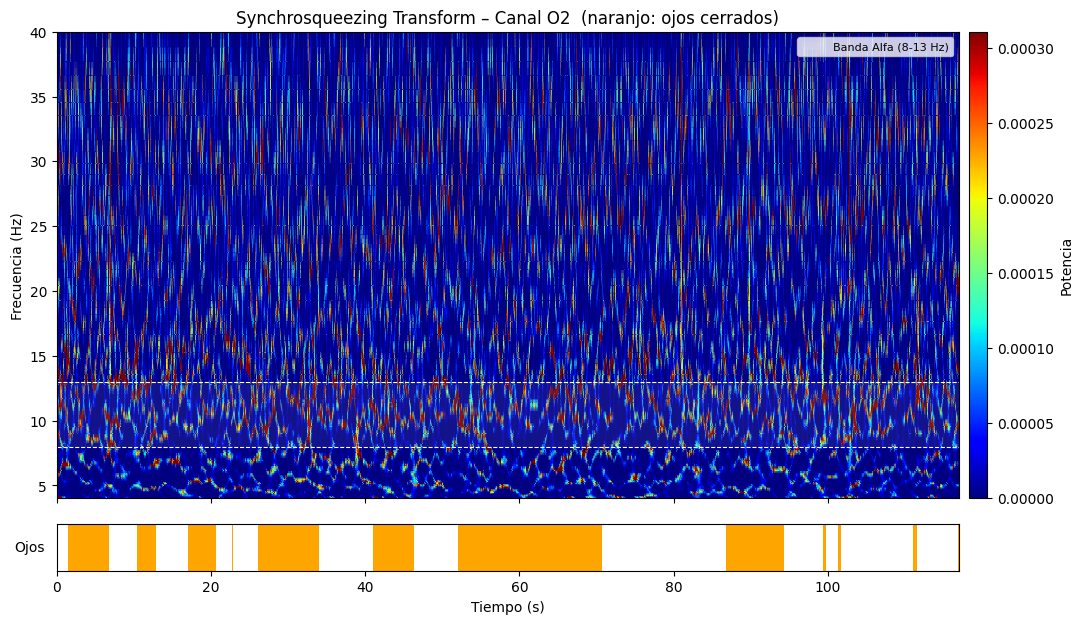

SST — shape por canal: (80, 14980)  (freqs x tiempo)
Frecuencias: 4.00 - 40.00 Hz  (80 bins)


In [39]:
# --- Computar SST para los 14 canales ---
sst_arrays = {}
sst_freqs_arr, sst_times_arr = None, None

for ch in CHANNELS:
    freqs_sst, t_sst, power = apply_sst(df[ch], fs=FS)
    sst_arrays[ch] = power
    if sst_freqs_arr is None:
        sst_freqs_arr = freqs_sst
        sst_times_arr = t_sst

# Misma resolución temporal que la CWT → mismo etiquetado directo
labels_sst = df[TARGET_COL].values

# --- Visualización O2 ---
target    = 'O2'
power_viz = sst_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(sst_times_arr, sst_freqs_arr, power_viz, shading='gouraud',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8-13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)
ax1.set_title(f'Synchrosqueezing Transform – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')
states_matrix = labels_sst.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[sst_times_arr.min(), sst_times_arr.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(sst_times_arr.min(), sst_times_arr.max())
ax2.set_xlim(sst_times_arr.min(), sst_times_arr.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

print(f"SST — shape por canal: {sst_arrays['O2'].shape}  (freqs x tiempo)")
print(f"Frecuencias: {sst_freqs_arr.min():.2f} - {sst_freqs_arr.max():.2f} Hz  "
      f"({len(sst_freqs_arr)} bins)")

## Wavelet Packet Decomposition (WPD)

La WPD es una generalización de la Transformada Wavelet Discreta (DWT)
estándar. Mientras la DWT solo descompone recursivamente la rama de
**aproximación** (frecuencias bajas) en cada nivel, la WPD descompone
**ambas** ramas — aproximación y detalle — en cada nivel, formando un árbol
binario completo. El resultado son sub-bandas de **igual ancho** que cubren
uniformemente todo el rango $[0, f_s/2]$, a diferencia de la DWT clásica
donde el ancho de banda decrece geométricamente hacia las frecuencias bajas.

Con un nivel de descomposición $L$, se obtienen $2^L$ sub-bandas, cada una
de ancho:

$$\Delta f = \frac{f_s/2}{2^L}$$

Con $f_s = 128$ Hz y $L = 4$: $\Delta f = 64/16 = 4$ Hz, produciendo 16
sub-bandas de 4 Hz cada una.

**Wavelet madre:** se usa Daubechies `db4`, estándar en la literatura EEG
para DWT/WPD por su soporte compacto y buena localización temporal —
distinta de la Morlet compleja usada en CWT/SST, que prioriza localización
conjunta tiempo-frecuencia sobre ortogonalidad.

**Limitación conocida — banda alfa no diádica:** a $f_s = 128$ Hz, la banda
alfa (8–13 Hz, ancho 5 Hz) no coincide con ninguna sub-banda diádica de 4 Hz.
Esto se cuantifica más abajo con el solapamiento real.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [41]:
def apply_wpd(series, fs=FS, level=4, wavelet='db4',
              window_sec=2, overlap_pct=0.75, freq_min=4, freq_max=40):
    """
    Aplica Wavelet Packet Decomposition (WPD) sobre ventanas deslizantes,
    produciendo una representación tiempo-frecuencia basada en la energía
    de cada sub-banda diádica del árbol de paquetes wavelet.

    Se calcula el árbol completo (0 a fs/2) y luego se recortan las
    sub-bandas al rango [freq_min, freq_max], replicando la misma decisión
    metodológica aplicada a la STFT: excluir la banda delta evita que la
    naturaleza 1/f del EEG (potencia mucho mayor en bajas frecuencias)
    domine la escala y oculte la dinámica de la banda alfa de interés.

    Parámetros
    ----------
    series      : array-like - Señal de entrada (1D).
    fs          : int        - Frecuencia de muestreo en Hz.
    level       : int        - Nivel de descomposición. level=4 produce
                               2^4 = 16 sub-bandas de fs/2/16 = 4 Hz cada
                               una (a fs=128 Hz), cubriendo 0-64 Hz.
    wavelet     : str        - Wavelet madre (Daubechies db4 por defecto).
    window_sec  : float      - Largo de ventana en segundos (igual a STFT).
    overlap_pct : float      - Solapamiento entre ventanas (igual a STFT).
    freq_min    : float      - Frecuencia mínima a conservar (Hz).
    freq_max    : float      - Frecuencia máxima a conservar (Hz).

    Retorna
    -------
    freqs : ndarray - Frecuencias centrales de las sub-bandas conservadas (Hz).
    t     : ndarray - Tiempo central de cada ventana (s).
    power : ndarray - Potencia por sub-banda y ventana (n_bands_recortadas x n_windows).
    """
    signal    = np.array(series, dtype=np.float64)
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)
    hop       = n_per_seg - n_overlap

    n_bands_total = 2 ** level
    band_width    = (fs / 2) / n_bands_total
    freqs_all     = (np.arange(n_bands_total) + 0.5) * band_width

    starts = list(range(0, len(signal) - n_per_seg + 1, hop))
    power_all = np.zeros((n_bands_total, len(starts)))
    t = np.zeros(len(starts))

    for k, start in enumerate(starts):
        segment = signal[start : start + n_per_seg]
        wp = pywt.WaveletPacket(data=segment, wavelet=wavelet,
                                mode='symmetric', maxlevel=level)
        nodes = wp.get_level(level, order='freq')
        for i, node in enumerate(nodes):
            power_all[i, k] = np.mean(node.data ** 2)

        t[k] = (start + n_per_seg / 2) / fs

    # Recorte a [freq_min, freq_max] — consistente con STFT/CWT/SST
    band_lo_edges = freqs_all - band_width / 2
    band_hi_edges = freqs_all + band_width / 2
    mask = (band_lo_edges >= freq_min - 1e-6) & (band_hi_edges <= freq_max + 1e-6)

    freqs = freqs_all[mask]
    power = power_all[mask, :]

    return freqs, t, power

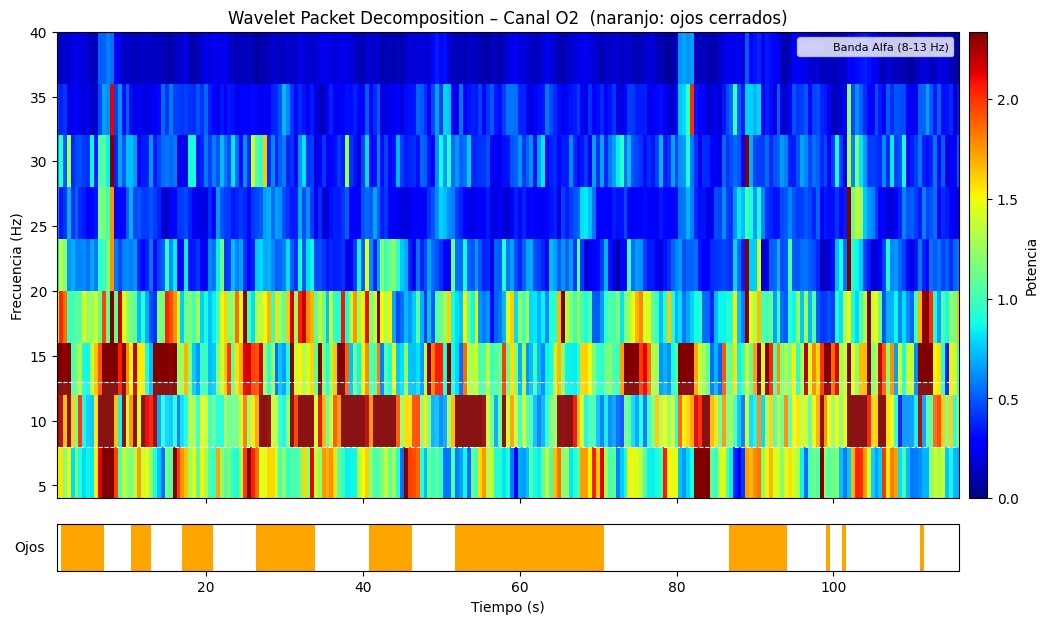

WPD — shape por canal: (9, 231)  (sub-bandas x ventanas)
Frecuencias centrales (Hz): [ 6. 10. 14. 18. 22. 26. 30. 34. 38.]


In [42]:
# --- Computar WPD para los 14 canales ---
wpd_arrays = {}
wpd_freqs_arr, wpd_times_arr = None, None

for ch in CHANNELS:
    freqs_wpd, t_wpd, power = apply_wpd(df[ch])
    wpd_arrays[ch] = power
    if wpd_freqs_arr is None:
        wpd_freqs_arr = freqs_wpd
        wpd_times_arr = t_wpd

labels_wpd = np.array([
    df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL]
    for ti in wpd_times_arr
])

# --- Visualización O2 ---
target    = 'O2'
power_viz = wpd_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(wpd_times_arr, wpd_freqs_arr, power_viz, shading='nearest',
                    cmap='jet', vmin=0, vmax=np.percentile(power_viz, 95))
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8-13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)
ax1.set_title(f'Wavelet Packet Decomposition – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')
states_matrix = labels_wpd.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[wpd_times_arr.min(), wpd_times_arr.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(wpd_times_arr.min(), wpd_times_arr.max())
ax2.set_xlim(wpd_times_arr.min(), wpd_times_arr.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

print(f"WPD — shape por canal: {wpd_arrays['O2'].shape}  (sub-bandas x ventanas)")
print(f"Frecuencias centrales (Hz): {np.round(wpd_freqs_arr, 1)}")

### Nota: exclusión de la banda delta en WPD

Al igual que en la STFT, se recortó el análisis WPD al rango 4–40 Hz,
excluyendo la sub-banda [0,4) Hz. Esta decisión es necesaria por dos
razones:

1. **Consistencia metodológica:** mantiene el mismo rango de análisis usado
   en STFT, CWT y SST, garantizando que las comparaciones entre técnicas
   sean justas.
2. **Naturaleza 1/f del EEG:** la potencia espectral decae fuertemente con
   la frecuencia. Sin excluir la banda delta, su energía domina la escala
   de color y oculta visualmente la dinámica de la banda alfa de interés.

Con `level=4` esto deja 9 sub-bandas de 4 Hz cada una, cubriendo
exactamente [4,8), [8,12), ..., [36,40) Hz.

### Cuantificación de la limitación diádica

Con `level=4` y `fs=128 Hz`, cada sub-banda tiene 4 Hz de ancho. A
continuación se calcula explícitamente cuánto de la banda alfa (8–13 Hz)
cae en cada sub-banda.

In [43]:
LEVEL      = 4
band_width = (FS / 2) / (2 ** LEVEL)
band_edges = np.arange(0, FS / 2 + band_width, band_width)

print(f"Bordes de las {2**LEVEL} sub-bandas (Hz), ancho = {band_width:.1f} Hz:")
print(band_edges)

alpha_lo, alpha_hi = 8.0, 13.0
print(f"\nSolape de cada sub-banda con la banda alfa ({alpha_lo}-{alpha_hi} Hz):")
for lo, hi in zip(band_edges[:-1], band_edges[1:]):
    overlap = max(0, min(hi, alpha_hi) - max(lo, alpha_lo))
    if overlap > 0:
        pct = 100 * overlap / (alpha_hi - alpha_lo)
        print(f"  [{lo:.0f}, {hi:.0f}) Hz  →  {overlap:.1f} Hz de solape  "
              f"({pct:.0f}% de la banda alfa)")

Bordes de las 16 sub-bandas (Hz), ancho = 4.0 Hz:
[ 0.  4.  8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60. 64.]

Solape de cada sub-banda con la banda alfa (8.0-13.0 Hz):
  [8, 12) Hz  →  4.0 Hz de solape  (80% de la banda alfa)
  [12, 16) Hz  →  1.0 Hz de solape  (20% de la banda alfa)


### Interpretación

La banda alfa completa **no cae en ninguna sub-banda única**: el 80% (8–12 Hz)
queda en una sub-banda y el 20% restante (12–13 Hz) en la siguiente. Usar
solo la sub-banda `[8,12)` para representar "potencia alfa" subestima
sistemáticamente la energía real de la banda, perdiendo el extremo superior.

**¿Por qué no subir el nivel de descomposición para ajustar mejor?** Con
`db4` (filtro de 8 coeficientes), el soporte efectivo del wavelet crece
aproximadamente como $(L_{filtro}-1)(2^{nivel}-1)+1$. Con `level=6`
(sub-bandas de 1 Hz, que sí encajarían exactamente en 8–13 Hz), ese soporte
ronda los 442 puntos — mayor que la ventana de 256 muestras usada — lo que
produce artefactos de borde severos. El nivel 4 es el balance práctico entre
resolución frecuencial y validez de la descomposición dentro de la ventana.

**Implicación para la extracción de features (notebook 03):** al calcular
potencia alfa desde WPD, se deberá combinar la sub-banda `[8,12)` completa
con una fracción ponderada de `[12,16)` (proporcional al 20% de solape), en
lugar de usar una sola sub-banda. Esta limitación debe documentarse
explícitamente en el reporte como una desventaja inherente de la WPD frente
a STFT/CWT/SST para este caso de uso específico.

## Guardado y Verificacion

In [44]:
from pathlib import Path

save_dir = Path('./data/tf_representations')
save_dir.mkdir(parents=True, exist_ok=True)

# ── Guardar ────────────────────────────────────────────────────────────────
np.savez(save_dir / 'stft.npz',
         **stft_arrays,
         freqs=stft_freqs, times=stft_times, labels=labels_stft)

np.savez(save_dir / 'cwt.npz',
         **cwt_arrays,
         freqs=cwt_freqs_arr, times=cwt_times_arr, labels=labels_cwt)

np.savez(save_dir / 'sst.npz',
         **sst_arrays,
         freqs=sst_freqs_arr, times=sst_times_arr, labels=labels_sst)

np.savez(save_dir / 'wpd.npz',
         **wpd_arrays,
         freqs=wpd_freqs_arr, times=wpd_times_arr, labels=labels_wpd)

# ── Verificar ──────────────────────────────────────────────────────────────
print(f"Archivos guardados en: {save_dir.resolve()}\n")

for name in ['stft.npz', 'cwt.npz', 'sst.npz', 'wpd.npz']:
    data = np.load(save_dir / name)
    print(f"{name}:")
    print(f"  Claves     : {list(data.keys())}")
    print(f"  Shape O2   : {data['O2'].shape}")
    print(f"  Shape freqs: {data['freqs'].shape}  |  times: {data['times'].shape}  |  labels: {data['labels'].shape}")
    print(f"  Clases     : {np.unique(data['labels'])}")
    print(f"  Canales OK : {all(ch in data for ch in CHANNELS)}")
    print()

Archivos guardados en: C:\Users\alfre\Documents\GitHub\Proyecto_INF405\data\tf_representations

stft.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2   : (73, 236)
  Shape freqs: (73,)  |  times: (236,)  |  labels: (236,)
  Clases     : [0. 1.]
  Canales OK : True

cwt.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2   : (80, 14980)
  Shape freqs: (80,)  |  times: (14980,)  |  labels: (14980,)
  Clases     : [0 1]
  Canales OK : True

sst.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2   : (80, 14980)
  Shape freqs: (80,)  |  times: (14980,)  |  labels: (14980,)
  Clases     : [0 1]
  Canales OK : True

wpd.npz:
  Claves     : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6